# Compare models


## Load results from models
Format : liste [num de frame, x_centroïde, y_centroïde, confiance]

### YOLO

In [53]:
import cv2
from ultralytics import YOLO

def extraire_centroid_balle_bbox(model_path, target_class, video_path, frame_step=1):
    # 1. Chargement du modèle
    model = YOLO(model_path)
    
    # Identification de l'ID de la classe
    class_ids = {v: k for k, v in model.names.items()}
    if target_class not in class_ids:
        print(f"Classe '{target_class}' introuvable.")
        return []
    target_id = class_ids[target_class]

    cap = cv2.VideoCapture(video_path)
    resultats_centroids = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

       # if frame_idx % frame_step == 0:
            # Inférence
        results = model(frame, verbose=False)[0]
        
        # On parcourt les boîtes détectées
        for box in results.boxes:
            cls_id = int(box.cls[0])
            if cls_id == target_id:
                # On peut utiliser .xywh qui donne directement le centre (x, y)
                # format : [x_centre, y_centre, largeur, hauteur]
                x_c, y_c, w, h = box.xywh[0].tolist()
                
                conf = float(box.conf[0])
                
                # On stocke : [Frame, Centroïde_X, Centroïde_Y, Confiance]
                resultats_centroids.append([frame_idx, int(x_c), int(y_c), conf])

        frame_idx += 1

    cap.release()
    return resultats_centroids



In [54]:
yolo_immobile = extraire_centroid_balle_bbox("roboflow/models/best-2.pt", "ball", "roboflow/dataset_labelise/video_immobile/video_immobile.mp4", frame_step=10)
for res in yolo_immobile[:10]:
    print(f"Frame {res[0]} : X={res[1]}, Y={res[2]}, Conf={res[3]}")

Frame 0 : X=341, Y=361, Conf=0.9754864573478699
Frame 1 : X=341, Y=361, Conf=0.9766066670417786
Frame 2 : X=341, Y=361, Conf=0.9757737517356873
Frame 3 : X=341, Y=361, Conf=0.9759584665298462
Frame 4 : X=341, Y=361, Conf=0.9750316739082336
Frame 5 : X=341, Y=361, Conf=0.9751887917518616
Frame 6 : X=341, Y=361, Conf=0.9728834629058838
Frame 7 : X=341, Y=361, Conf=0.9739896059036255
Frame 8 : X=341, Y=361, Conf=0.9728358387947083
Frame 9 : X=341, Y=361, Conf=0.9718772768974304


In [ ]:
yolo_lent = extraire_centroid_balle_bbox("roboflow/models/best-2.pt", "ball", "roboflow/dataset_labelise/video_lente/video_lente.mp4", frame_step=5)
yolo_simple = extraire_centroid_balle_bbox("roboflow/models/best-2.pt", "ball", "roboflow/dataset_labelise/video_simple/video_simple.mp4", frame_step=5)

### CV2

In [1]:
import cv2
import numpy as np
from utils.tracking_utils_2D import BallTracker, PlayerDetector, TablePnPEstimator

clicked_points = []

def mouse_callback(event, x, y, flags, param):
    global clicked_points
    if event == cv2.EVENT_LBUTTONDOWN and len(clicked_points) < 4:
        clicked_points.append((x, y))

def main(video_path):
    global clicked_points
    ball_positions = [] 
    
    VIDEO_PATH = video_path
    WINDOW_MAIN = "Smart Tracker (Video)"
    TARGET_WIDTH = 800
    LOOP_VIDEO = False 

    cv2.namedWindow(WINDOW_MAIN, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(WINDOW_MAIN, mouse_callback)

    ball_tracker = BallTracker(buffer_size=32, max_jump_dist=400, window_name=WINDOW_MAIN)
    ball_tracker.setup_trackbars()
    player_detector = PlayerDetector()

    stream = cv2.VideoCapture(VIDEO_PATH)
    if not stream.isOpened(): return []

    ret, initial_frame = stream.read()
    if not ret: return []
    
    height, width = initial_frame.shape[:2]

    pnp_estimator = TablePnPEstimator(frame_width=width, frame_height=height)
    
    while len(clicked_points) < 4:
        temp_frame = initial_frame.copy()
        for pt in clicked_points:
            cv2.circle(temp_frame, pt, 5, (0, 255, 255), -1)
        
        instruction = f"Click 4 corners: Net L, Near L, Near R, Net R ({len(clicked_points)}/4)"
        cv2.putText(temp_frame, instruction, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
        cv2.imshow(WINDOW_MAIN, temp_frame)
        if cv2.waitKey(1) == ord('q'): return []

    pnp_estimator.update_camera_pose(clicked_points)
    stream.set(cv2.CAP_PROP_POS_FRAMES, 0)

    display_text = ""
    display_timer = 0

    print("Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.")

    while True:
        current_frame_idx = int(stream.get(cv2.CAP_PROP_POS_FRAMES))
        
        ret, frame = stream.read()
        if not ret:
            break 

        
        cv2.polylines(frame, [np.int32(clicked_points)], True, (0, 255, 0), 2)
        for pt in clicked_points:
            cv2.circle(frame, pt, 5, (0, 255, 255), -1)

        frame = player_detector.process(frame)
        frame, ball_center, ball_w = ball_tracker.process(frame)
        
        if ball_center is not None:
            conf = getattr(ball_tracker, 'last_confidence', 1.0)
            ball_positions.append([
                current_frame_idx, 
                round(ball_center[0], 2), 
                round(ball_center[1], 2), 
                round(conf, 2)
            ])
        

        if display_timer > 0:
            color = (0, 255, 0) if "IN" in display_text else (0, 0, 255)
            cv2.putText(frame, display_text, (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 4, cv2.LINE_AA)
            display_timer -= 1

        cv2.imshow(WINDOW_MAIN, frame)

        if cv2.waitKey(1) == ord('q'): break

    stream.release()
    cv2.destroyAllWindows()
    
    return ball_positions


In [4]:
CV2_ball_immobile = main("roboflow/dataset_labelise/video_immobile/video_immobile.mp4")
for res in CV2_ball_immobile[:10]:
    print(f"Frame {res[0]} : X={res[1]}, Y={res[2]}, Conf={res[3]}")

Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.
Frame 0 : X=341, Y=364, Conf=1.0


I0000 00:00:1775990453.293120  220313 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1775990453.382498  221987 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775990453.399080  221986 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [2]:
CV2_ball_lente = main("roboflow/dataset_labelise/video_lente/video_lente.mp4")
CV2_ball_simple = main("roboflow/dataset_labelise/video_simple/video_simple.mp4")


I0000 00:00:1775990389.950879  220313 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775990390.064922  220627 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775990390.082328  220627 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.


W0000 00:00:1775990397.277993  220622 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
I0000 00:00:1775990409.871715  220313 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1775990409.962659  221231 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775990409.980006  221231 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Analyse lancée... Appuyez sur 'q' pour arrêter et récupérer les données.


### Basic CV2


In [ ]:
import cv2
import numpy as np

def extraire_coords_hsv(video_name, video_path, frame_step=1):
    """
    Détecte la balle par couleur HSV et renvoie les centroïdes.
    Sortie : Liste de [num_frame, x_centroïde, y_centroïde, confiance]
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Erreur : Impossible d'ouvrir la vidéo {video_path}")
        return []

    lower_color = np.array([5, 150, 150])
    upper_color = np.array([15, 255, 255])

    resultats = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % frame_step == 0:
            hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            mask = cv2.inRange(hsv, lower_color, upper_color)

            mask = cv2.medianBlur(mask, 5)
            mask = cv2.dilate(mask, None, iterations=2)

            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for cnt in contours:
                area = cv2.contourArea(cnt)
                if area > 50:  # Filtre de taille minimum
                    (x, y), radius = cv2.minEnclosingCircle(cnt)
                    resultats.append([frame_idx, int(x), int(y), 1.0])
                    break 

        frame_idx += 1

    cap.release()
    return resultats


In [11]:

basic_immobile_ball = extraire_coords_hsv("video_immobile", "roboflow/dataset_labelise/video_immobile/video_immobile.mp4", frame_step=15)
print("Exemple de résultats (frame, x, y, conf) :")
for res in basic_immobile_ball[:10]:
    print(res)

Exemple de résultats (frame, x, y, conf) :
[0, 341, 369, 1.0]
[15, 341, 369, 1.0]
[30, 340, 368, 1.0]
[45, 340, 368, 1.0]
[60, 340, 369, 1.0]
[75, 340, 369, 1.0]
[90, 340, 369, 1.0]
[105, 340, 369, 1.0]
[120, 339, 370, 1.0]
[135, 339, 370, 1.0]


In [ ]:

basic_lente_ball = extraire_coords_hsv("video_lente", "roboflow/dataset_labelise/video_lente/video_lente.mp4", frame_step=15)
basic_simple_ball = extraire_coords_hsv("video_simple", "roboflow/dataset_labelise/video_simple/video_simple.mp4", frame_step=15)

Exemple de résultats (frame, x, y, conf) :
[15, 604, 234, 1.0]
[30, 547, 323, 1.0]
[45, 545, 392, 1.0]
[60, 571, 430, 1.0]
[75, 569, 428, 1.0]
[90, 476, 194, 1.0]
[105, 442, 299, 1.0]
[120, 447, 410, 1.0]
[135, 455, 406, 1.0]
[150, 472, 404, 1.0]


## Comparaison avec le fichier labellisé

In [3]:
import pandas as pd
import numpy as np

def calculer_distances_eucl(video_nom_cible, results, csv_path):
    # Chargement et nettoyage du Ground Truth
    df_gt = pd.read_csv(csv_path)
    cols = df_gt.columns
    col_video, col_frame = cols[0], cols[1]
    cols_coords = [cols[2], cols[3], cols[4], cols[5]]

    # On ne garde que la vidéo cible et les frames annotées
    df_video = df_gt[df_gt[col_video] == video_nom_cible].copy()
    df_video = df_video.dropna(subset=cols_coords)

    if df_video.empty:
        print(f"Aucune annotation valide pour {video_nom_cible}")
        return [], []

    # Calcul des centroïdes GT
    df_video['cx_gt'] = (df_video[cols[2]] + df_video[cols[4]]) / 2
    df_video['cy_gt'] = (df_video[cols[3]] + df_video[cols[5]]) / 2
    gt_map = df_video.set_index(col_frame)[['cx_gt', 'cy_gt']].to_dict('index')

    # Création d'un dictionnaire {frame_idx: (cx, cy)} pour matcher rapidement
    res_dict = {res[0]: (res[1], res[2]) for res in results}

    distances_finales = []
    # Liste des frames où la balle est censée être
    frames_gt = sorted(gt_map.keys()) 

    for f_idx in frames_gt:
        if f_idx in res_dict:
            cx_mod, cy_mod = res_dict[f_idx]
            gt_cx = gt_map[f_idx]['cx_gt']
            gt_cy = gt_map[f_idx]['cy_gt']
            dist = np.sqrt((cx_mod - gt_cx)**2 + (cy_mod - gt_cy)**2)
            
            distances_finales.append(dist)
        else:
            # Si l'idx n'est pas détecté par le modèle -> NaN
            distances_finales.append(np.nan)

    # Vérification : les deux listes doivent avoir la même taille
    print(f"Taille GT: {len(frames_gt)} | Taille Distances: {len(distances_finales)}", distances_finales, frames_gt)
    
    return distances_finales, frames_gt

In [ ]:
error_yolo_immobile, frames_yolo_immobile = calculer_distances_eucl("video_immobile", yolo_immobile, "roboflow/dataset_labelise/annotations.csv")
error_yolo_lente, frames_yolo_lente = calculer_distances_eucl("video_lente", yolo_lent, "roboflow/dataset_labelise/annotations.csv")
error_yolo_simple, frames_yolo_simple = calculer_distances_eucl("video_simple", yolo_simple, "roboflow/dataset_labelise/annotations.csv")

Taille GT: 17 | Taille Distances: 17 [0.456207189772359, 0.7280453282591681, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488, 1.6087650543196488] [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240]


In [5]:
error_CV2_immobile, frames_CV2_immobile = calculer_distances_eucl("video_immobile", CV2_ball_immobile, "roboflow/dataset_labelise/annotations.csv")
error_CV2_lente, frames_CV2_lente = calculer_distances_eucl("video_lente", CV2_ball_lente, "roboflow/dataset_labelise/annotations.csv")
error_CV2_simple, frames_CV2_simple = calculer_distances_eucl("video_simple", CV2_ball_simple, "roboflow/dataset_labelise/annotations.csv")

Taille GT: 17 | Taille Distances: 17 [2.8192419193818354, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan] [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240]
Taille GT: 19 | Taille Distances: 19 [4.861792364961717, 12.899786819943978, 49.57831481605643, 0.7262231062145552, 1.536400013017483, 1.3446189051177302, 10.61292136972658, 3.5025847598594946, 4.615213971204355, 7.100852061548693, 4.856346363265329, 2.070809020648691, 1.9705963564363076, 407.09898836155315, 35.56291221202224, 10.320945935329798, 5.3976777413995185, 2.0053989628001663, 2.288105111221952] [15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285]
Taille GT: 11 | Taille Distances: 11 [0.9701675113092613, 33.995044491807924, 40.749926380301616, 88.53486460146645, 5.619688603472617, 7.797020264177877, nan, nan, nan, nan, 17.03498238918959] [5, 10, 55, 60, 65, 70, 75, 105, 110, 115, 120]


In [22]:
error_basic_immobile, frames_basic_immobile = calculer_distances_eucl("video_immobile", basic_immobile_ball, "roboflow/dataset_labelise/annotations.csv")
error_basic_lente, frames_basic_lente = calculer_distances_eucl("video_lente", basic_lente_ball, "roboflow/dataset_labelise/annotations.csv")
error_basic_simple, frames_basic_simple = calculer_distances_eucl("video_simple", basic_simple_ball, "roboflow/dataset_labelise/annotations.csv")

Taille GT: 17 | Taille Distances: 17 [7.800520815945523, 7.406081960118975, 7.268983766662274, 7.268983766662274, 8.210854096864685, 8.210854096864685, 8.210854096864685, 8.210854096864685, 9.496742862687162, 9.496742862687162, 7.95161147189672, 7.95161147189672, 7.95161147189672, 7.95161147189672, 7.95161147189672, 7.95161147189672, 8.210854096864685] [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240]
Taille GT: 19 | Taille Distances: 19 [0.4207433897282431, 0.5869412236331413, 21.367482303725012, 13.658235610795353, 12.080584629892655, 1.3446189051177302, 3.5205255289516395, 15.01825888710134, 22.548618582964213, 25.860048337155114, nan, 2.9846691608953906, 3.7580912708448238, 16.663322747879544, 15.53160407041076, 18.89846356188781, 13.07764982709048, 2.5380356577479475, 23.156973571691097] [15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285]
Taille GT: 11 | Taille Distances: 11 [nan, nan, nan, 9.766895617339195, nan, n

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_error_comparison(frames, errors_yolo, errors_manual, error_basic, threshold=60):
    y = np.array(errors_yolo, dtype=float)
    m = np.array(errors_manual, dtype=float)
    b = np.array(error_basic, dtype=float)
    f = np.array(frames)
    for i in range(len(f)):
        if y[i] > threshold:
            print(f"Frame {f[i]} : Erreur YOLO = {y[i]:.2f}")
        if m[i] > threshold:
            print(f"Frame {f[i]} : Erreur BallTracker = {m[i]:.2f}")
        if b[i] > threshold:
            print(f"Frame {f[i]} : Erreur Basic = {b[i]:.2f}")
    # On remplace par NaN toutes les valeurs qui dépassent le seuil
    y[y > threshold] = np.nan
    m[m > threshold] = np.nan
    b[b > threshold] = np.nan

    plt.figure(figsize=(16, 8))
    
    plt.plot(f, y, label='Erreur YOLO', color='blue', 
             marker='o', markersize=10, linestyle='None', alpha=0.7)
    
    plt.plot(f, m, label='Erreur BallTracker', color='red', 
             marker='o', markersize=10, linestyle='None', alpha=0.7)
    
    plt.plot(f, b, label='Erreur Basic', color='green', 
             marker='o', markersize=10, linestyle='None', alpha=0.7)
    
    plt.xticks(f, rotation=45)
    plt.ylim(0, threshold + 5) 
    
    plt.title(f"Précision du Tracking (Seuil max : {threshold}px)")
    plt.xlabel("Numéro de la Frame")
    plt.ylabel("Distance L2 (pixels)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.axhline(y=80, color='black', linestyle=':', alpha=0.5, label="Seuil")
    
    plt.tight_layout()
    plt.show()



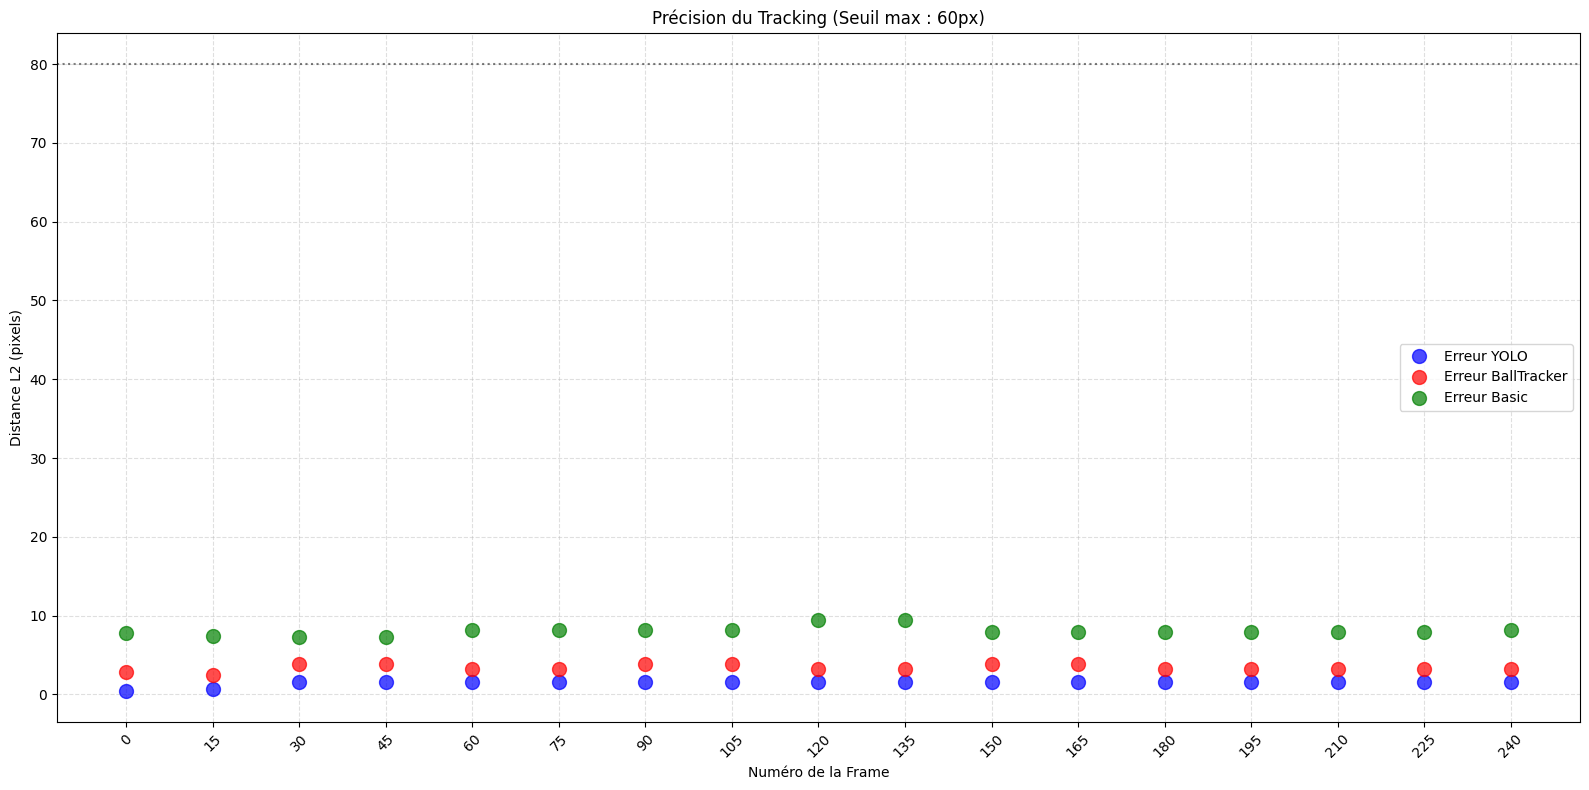

In [57]:
plot_error_comparison(frames_yolo_immobile, error_yolo_immobile, error_CV2_immobile, error_basic_immobile )

In [26]:
print(len(error_yolo_immobile), len(error_CV2_immobile), len(error_basic_immobile))

17 17 17


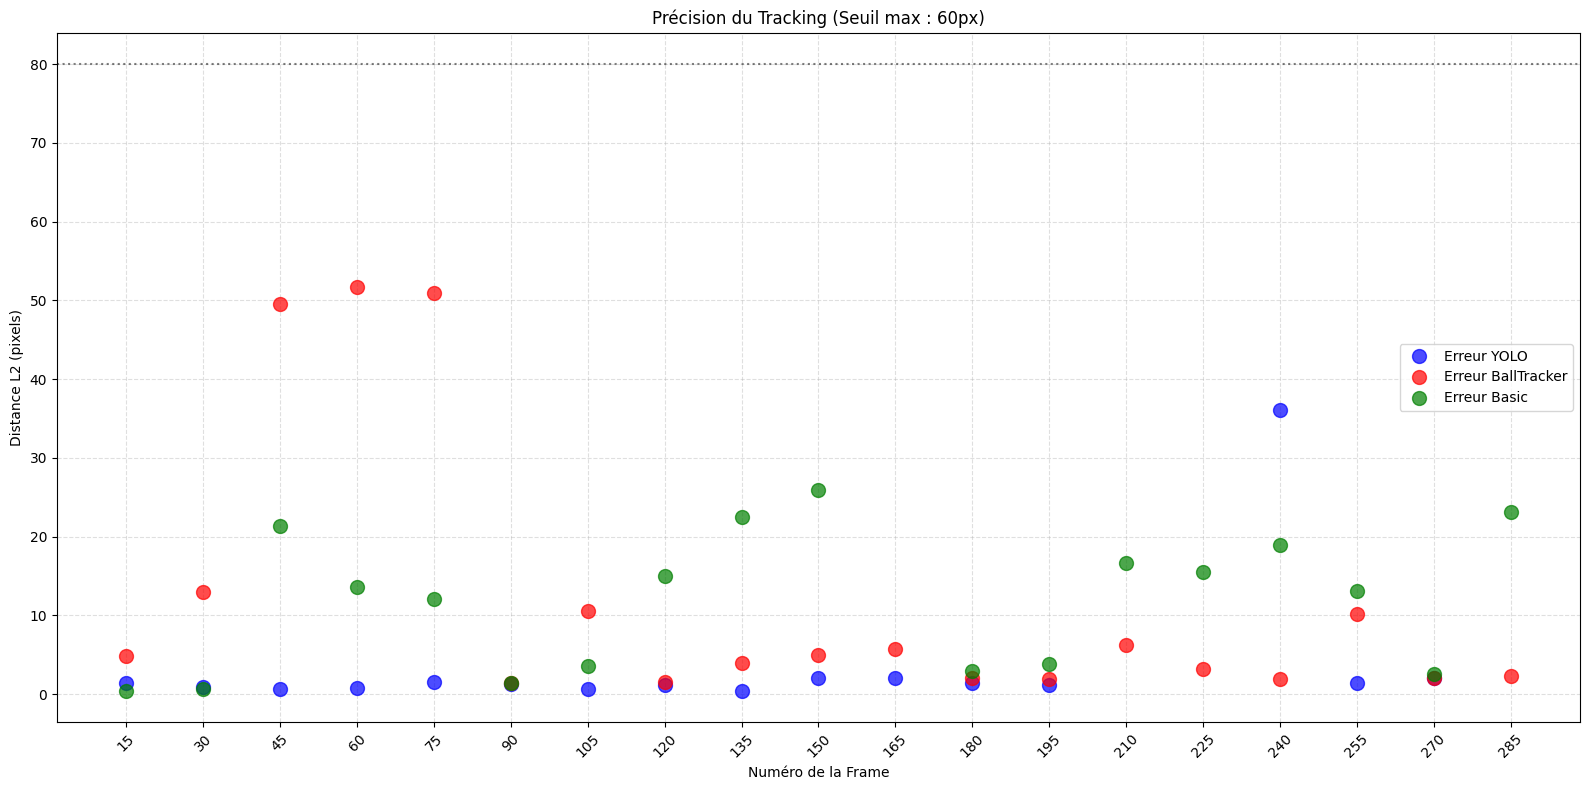

In [46]:
plot_error_comparison(frames_yolo_lente, error_yolo_lente, error_CV2_lente, error_basic_lente )

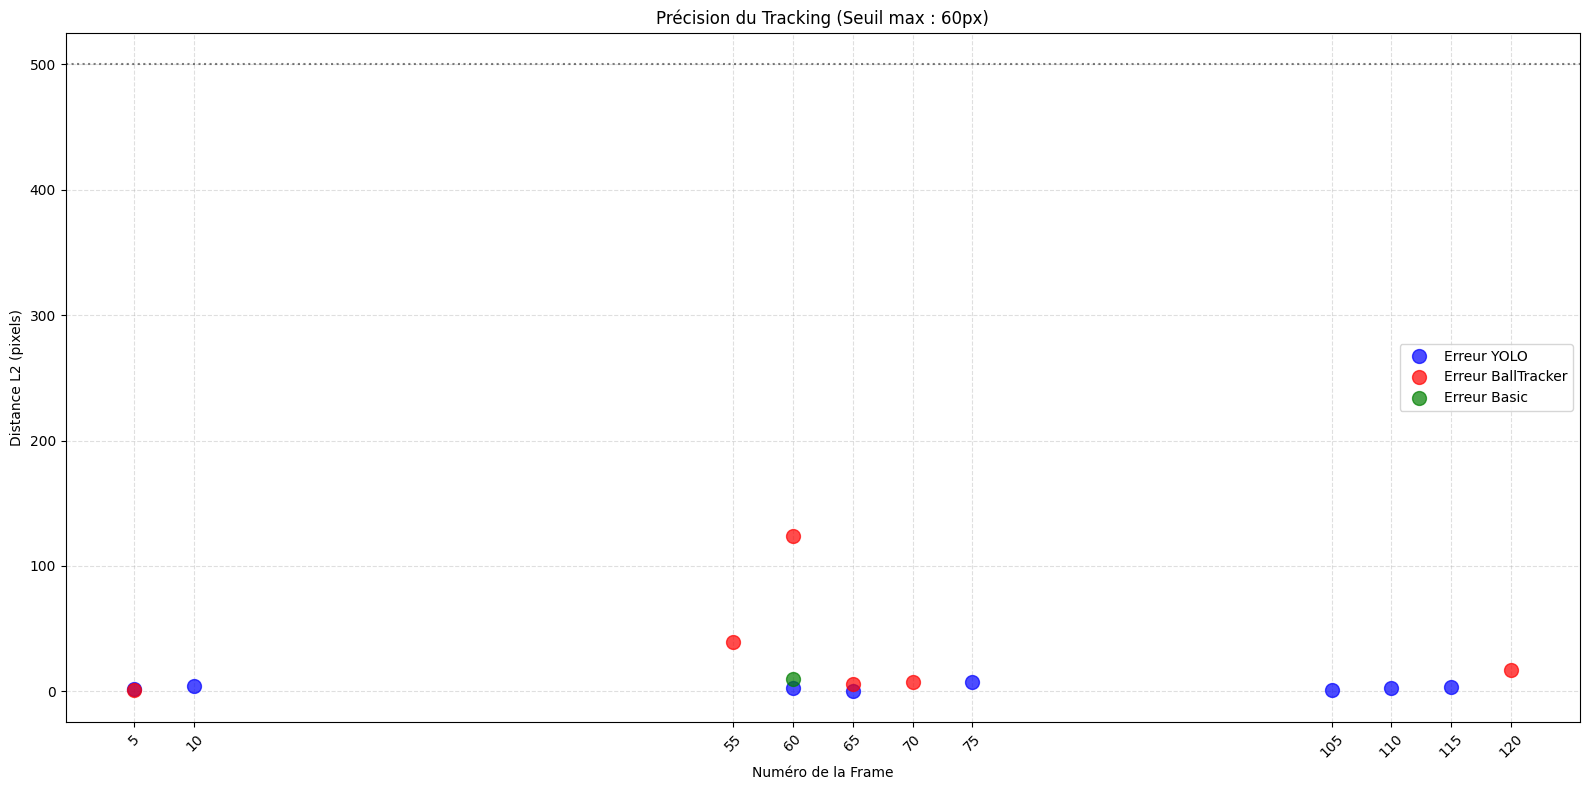

In [44]:
plot_error_comparison(frames_yolo_simple, error_yolo_simple, error_CV2_simple, error_basic_simple )

In [7]:
import cv2
import os

def outliers_visualizor(video_path, liste_frames,liste_resultats):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Erreur : Impossible d'ouvrir la vidéo.")
        return

    for f_idx in sorted(liste_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
        ret, img = cap.read()
        detection = next((res for res in liste_resultats if res[0] == f_idx), None)

        if detection is None:
            print(f"Aucune donnée de détection pour la frame {f_idx} dans la liste.")
            return

        _, cx, cy, conf = detection    
        if img is None:
            print(f"Erreur lors de la lecture de l'image.")
            return
        pos = (int(cx), int(cy))
        cv2.circle(img, pos, 12, (0, 0, 255), 3) 
        cv2.circle(img, pos, 2, (0, 0, 255), -1) 

        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Visualisation de l'erreur - Frame {f_idx}")
        plt.axis('off')
        plt.show()
    cap.release()

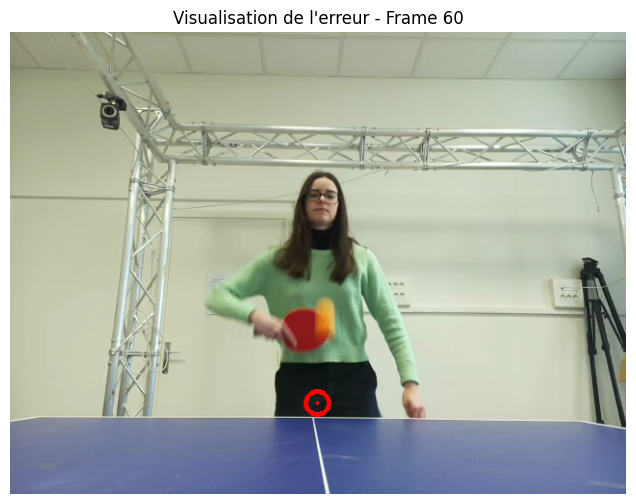

In [10]:
resultats_hsv =CV2_ball_simple
outliers_visualizor("roboflow/dataset_labelise/video_simple/video_simple.mp4", [60]
                , resultats_hsv)

In [34]:
import numpy as np
import pandas as pd

def evaluer_precision_modeles(dict_erreurs):
    """
    Prend un dictionnaire de listes d'erreurs (contenant des NaN)
    Ex: {'YOLO': errors_yolo, 'BallTracker': errors_manual, 'Basic': error_basic}
    """
    stats = []
    
    for nom_modele, liste_err in dict_erreurs.items():
        err_array = np.array(liste_err, dtype=float)
        
        # 1. On filtre les NaN pour les calculs de distance
        masque_valide = ~np.isnan(err_array)
        erreurs_valides = err_array[masque_valide]
        
        # 2. Calcul des métriques
        if len(erreurs_valides) > 0:
            mae = np.mean(erreurs_valides)
            rmse = np.sqrt(np.mean(erreurs_valides**2))
            max_err = np.max(erreurs_valides)
            taux_detection = (len(erreurs_valides) / len(err_array)) * 100
        else:
            mae, rmse, max_err, taux_detection = 0, 0, 0, 0

        stats.append({
            "Modèle": nom_modele,
            "MAE (px)": round(mae, 2),
            "RMSE (px)": round(rmse, 2),
            "Erreur Max (px)": round(max_err, 2),
            "Détection (%)": round(taux_detection, 1)
        })
    
    return pd.DataFrame(stats)


In [58]:
mes_erreurs = {
    "YOLO": error_yolo_lente+error_yolo_simple+error_yolo_immobile, 
    "Computer Vision":   error_CV2_lente + error_CV2_simple+error_CV2_immobile, 
    "Basic":  error_basic_lente + error_basic_simple+error_basic_immobile
}

df_precision = evaluer_precision_modeles(mes_erreurs)
print(df_precision)

            Modèle  MAE (px)  RMSE (px)  Erreur Max (px)  Détection (%)
0             YOLO      2.54       5.99            36.08           87.2
1  Computer Vision     11.44      24.82           124.26           89.4
2            Basic     10.01      11.82            25.86           76.6


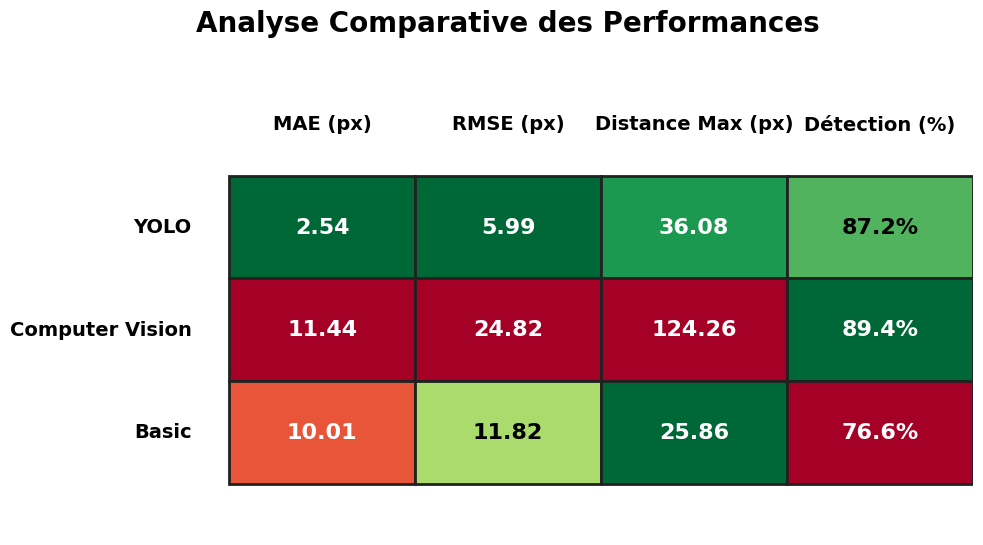

: 

In [ ]:
data = {
    'Modèle': ['YOLO', 'Computer Vision', 'Basic'],
    'MAE (px)': [2.54, 11.44, 10.01],
    'RMSE (px)': [5.99, 24.82, 11.82],
    'Distance Max (px)': [36.08, 124.26, 25.86],
    'Détection (%)': [87.2, 89.4, 76.6]
}
df = pd.DataFrame(data).set_index('Modèle')

def create_table_image(df, filename='tableau_comparatif_ping.png'):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('off')
    
    n_rows, n_cols = df.shape
    cols = df.columns
    rows = df.index

    cmap_errors = plt.get_cmap('RdYlGn_r') 
    cmap_detect = plt.get_cmap('RdYlGn')   

    for j, col in enumerate(cols):
        ax.text(j + 0.5, n_rows + 0.5, col, ha='center', va='center', 
                fontweight='bold', fontsize=14, color='black')
    
    for i, row_label in enumerate(rows):
        ax.text(-0.2, n_rows - i - 0.5, row_label, ha='right', va='center', 
                fontweight='bold', fontsize=14, color='black')

    for j, col in enumerate(cols):
        col_data = df[col].values
        v_min, v_max = col_data.min(), col_data.max()
        current_cmap = cmap_detect if 'Détection' in col else cmap_errors
        
        for i, val in enumerate(col_data):
            norm_val = (val - v_min) / (v_max - v_min) if v_max != v_min else 0.5
            color = current_cmap(norm_val)

            rect = plt.Rectangle((j, n_rows - i - 1), 1, 1, facecolor=color, edgecolor='#212121', linewidth=2)
            ax.add_patch(rect)

            display_text = f"{val:.2f}" if 'Détection' not in col else f"{val:.1f}%"

            lum = 0.299 * color[0] + 0.587 * color[1] + 0.114 * color[2]
            text_color = 'white' if lum < 0.5 else 'black'
            
            ax.text(j + 0.5, n_rows - i - 0.5, display_text, ha='center', va='center', 
                    fontweight='bold', fontsize=16, color=text_color)

    ax.set_xlim(-1, n_cols)
    ax.set_ylim(-0.5, n_rows + 1)
    plt.title("Analyse Comparative des Performances", fontsize=20, fontweight='bold', color='black', pad=30)

    fig.patch.set_facecolor("#FFFFFF")
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

create_table_image(df)